# Proyecto Final - Machine Learning

# Sistema Inteligente para la Clasificación Automática de Tickets de Soporte utilizando Machine Learning

**Estudiante:** Daniel Vera

**Curso:** Machine Learning

**Fecha:** Agosto 2026

# Introducción

Las organizaciones que ofrecen soporte técnico reciben diariamente una gran cantidad de solicitudes relacionadas con activaciones de software, problemas de hardware, licencias, garantías, compras y consultas generales. Tradicionalmente, un agente debe revisar manualmente cada ticket para determinar el área encargada de atenderlo, lo que incrementa los tiempos de respuesta y puede generar errores de clasificación.

En este proyecto se desarrollará un sistema basado en técnicas de Machine Learning capaz de clasificar automáticamente los tickets de soporte a partir del texto contenido en el campo **Summary**. Para ello se implementarán diferentes modelos de clasificación y se comparará su desempeño mediante diversas métricas de evaluación.

El objetivo final es identificar el modelo que ofrece el mejor equilibrio entre precisión y capacidad de generalización, proporcionando una posible solución para optimizar el proceso de asignación automática de solicitudes.

# Objetivos

## Objetivo General

Desarrollar un modelo de Machine Learning capaz de clasificar automáticamente tickets de soporte técnico utilizando el resumen de cada solicitud.

## Objetivos Específicos

- Explorar y analizar el conjunto de datos.
- Realizar el preprocesamiento necesario sobre la información.
- Transformar el texto utilizando técnicas de vectorización.
- Entrenar tres algoritmos de clasificación.
- Comparar el desempeño de los modelos mediante diferentes métricas.
- Determinar cuál modelo resulta más adecuado para apoyar el proceso de clasificación automática de tickets.

In [222]:
# Importación de librerías

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

# Configuración de gráficos
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

In [223]:
# ==========================================
# Cargar dataset
# ==========================================

df = pd.read_csv("101000262764_tickets-August-03-2026-17_10.csv")

df.head()

,Ticket ID,Subject,Status,Type,Agent,Created time,Agent interactions,Product,Summary,Oracle ON,Country Americas,State US,Product type,French Product,German Product,Portugal Product,NL Product,English Product,Request Type,Serial Number,Contact Position,Request Topic General,Request Topic Software,Request Topic Hardware,Flag ETC,Flag ETC Reason,Request topic Sales/Marketing Admin,Hardware Date Code,Hardware OS,Chinese Product,Australian Product,APR Other Product,Chinese Product.1,Australian Product.1,APR Other Product.1,Software error message,US/Canada Product,Latin America Product,US/Canada Product.1,Latin America Product.1,US/Canada Software,Customer Type,Title,Full name,Email,Work phone,Mobile phone,Company Name,Address,Zip code,City,Country,Telephone
0,296198,"Other country, Warranty, Replace, or Troublesh...",Resolved,NaN,Brayan Pulido,2026-07-01 00:46:47,1,No Product,Out of scope.,NaN,NaN,NaN,General,NaN,NaN,NaN,NaN,NaN,Semiconductors,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Ifoldesi,ifoldesi@celestica.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,296205,NaN,Closed,NaN,Jose Patiño,2026-07-01 02:34:23,2,No Product,Unknown issue,NaN,NaN,NaN,General,NaN,NaN,NaN,NaN,NaN,General Inquiry/Info,NaN,NaN,Other,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yg Uh,uhy391999@gmail.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,296211,TEXAS INSTRUMENTS德州仪器计算器产品经销商咨询,Resolved,NaN,Juan Aldana,2026-07-01 03:50:00,1,No Product,semiconductor inquiry,NaN,NaN,NaN,General,NaN,NaN,NaN,NaN,NaN,Semiconductors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,授权,shouquan@haotion.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,296222,"TI-84 plus CE not charging, I guess",Closed,NaN,Karol Sanabria,2026-07-01 05:36:01,1,No Product,Battery not charging; directed customer to bat...,NaN,United States,North Carolina,Hardware,NaN,NaN,NaN,NaN,NaN,Hardware Issues,na,Student,Contact request,NaN,NaN,NaN,NaN,NaN,na,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TI-84 Plus CE,NaN,TI-84 Plus CE Python,NaN,NaN,Student,NaN,Ralph Coats,rcoats@chestnut-ent.com,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,296233,Calculator Purchase,Closed,NaN,Steven Garcia,2026-07-01 07:44:00,1,No Product,Customer Requesting Quote for charging cords a...,NaN,United States,New York,General,NaN,NaN,NaN,NaN,NaN,General Inquiry/Info,NaN,"School Admin (e.g. Principal, Superintendent)",Purchase information request,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"School Admin (e.g. Principal, Superintendent)",NaN,Arielle Fitzgerald,afitzgerald@lawrence.k12.ny.us,+15162957000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Auditoría del Conjunto de Datos

Antes de realizar el análisis exploratorio, es importante comprender la estructura del conjunto de datos e identificar cuáles variables son relevantes para el problema de clasificación.

Durante esta etapa se revisa cada columna para conocer su tipo de dato, cantidad de valores faltantes, número de valores únicos y un ejemplo de su contenido. Esta información permitirá seleccionar las variables que aportan valor al modelo y justificar la exclusión de aquellas que no serán utilizadas en el análisis.

El objetivo de esta auditoría es garantizar que el proceso de preparación de los datos se base en criterios técnicos y no únicamente en decisiones arbitrarias.

In [224]:
# ==========================================
# Auditoría del conjunto de datos
# ==========================================

auditoria = pd.DataFrame({
    "Tipo de dato": df.dtypes,
    "Valores no nulos": df.notnull().sum(),
    "Valores nulos": df.isnull().sum(),
    "% Nulos": round((df.isnull().sum() / len(df)) * 100, 2),
    "Valores únicos": df.nunique()
})

# Agregar un ejemplo de cada columna
auditoria["Ejemplo"] = [
    df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else "-"
    for col in df.columns
]

auditoria

,Tipo de dato,Valores no nulos,Valores nulos,% Nulos,Valores únicos,Ejemplo
Ticket ID,int64,2199,0,0.00,2199,296198
Subject,str,2197,2,0.09,1929,"Other country, Warranty, Replace, or Troublesh..."
Status,str,2199,0,0.00,5,Resolved
Type,str,181,2018,91.77,2,Sample Request
Agent,str,2199,0,0.00,26,Brayan Pulido
Created time,str,2199,0,0.00,2194,2026-07-01 00:46:47
Agent interactions,int64,2199,0,0.00,12,1
Product,str,2199,0,0.00,1,No Product
Summary,str,2199,0,0.00,1026,Out of scope.
Oracle ON,float64,616,1583,71.99,594,1568890.0


## Interpretación

La auditoría permite identificar la calidad y utilidad de cada variable antes de iniciar el análisis exploratorio.

A partir de esta revisión se observa que algunas columnas presentan una gran cantidad de valores faltantes o contienen un único valor para la mayoría de los registros, por lo que no aportan información relevante para el problema de clasificación. En contraste, variables como **Summary** y **Request Type** contienen la información necesaria para entrenar los modelos de Machine Learning, mientras que otras columnas como **Status**, **Country** o **Customer Type** podrán utilizarse para enriquecer el análisis exploratorio.

## Selección de Variables

Con base en la auditoría realizada, se definieron las variables que serán utilizadas durante el desarrollo del proyecto y aquellas que serán descartadas por no aportar información relevante al problema de clasificación.

## Selección de Variables

Con base en la auditoría realizada, se definieron las variables que serán utilizadas durante el desarrollo del proyecto y aquellas que serán descartadas por no aportar información relevante al problema de clasificación.

| Variable | Rol en el proyecto | Justificación |
|-----------|--------------------|---------------|
| Summary | Variable de entrada | Contiene el texto que describe cada solicitud y será la principal fuente de información para entrenar los modelos de clasificación. |
| Request Type | Variable objetivo | Corresponde a la categoría que el modelo deberá predecir. |
| Status | Análisis exploratorio | Permite conocer la distribución del estado de los tickets y comprender el contexto del conjunto de datos. |
| Country | Análisis exploratorio | Aporta información sobre la distribución geográfica de las solicitudes. |
| Customer Type | Análisis exploratorio | Permite caracterizar el tipo de cliente que genera las solicitudes de soporte. |
| Product | No utilizada | La mayoría de los registros contienen el valor **"No Product"**, por lo que no aporta información útil para el análisis ni para el entrenamiento del modelo. |
| Request Topic General | No utilizada | Presenta una alta proporción de valores faltantes, lo que limita su utilidad para el proyecto. |
| Request Topic Software | No utilizada | Contiene una gran cantidad de valores faltantes y no

# Comprensión y Exploración de los Datos (EDA)

Una vez identificadas las variables relevantes mediante la auditoría del conjunto de datos, se realiza el Análisis Exploratorio de Datos (EDA). Esta etapa tiene como propósito comprender las características generales del dataset, identificar posibles problemas de calidad y analizar la distribución de las variables de interés.

Los resultados obtenidos permitirán establecer una base sólida para la limpieza y el preprocesamiento de los datos, garantizando que los modelos de Machine Learning sean entrenados con información de calidad.

## Dimensiones del Dataset

En esta sección se verifica el tamaño del conjunto de datos, identificando el número de registros y variables disponibles para el análisis.

In [225]:
print("="*50)
print("Dimensiones del Dataset")
print("="*50)

print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Dimensiones del Dataset
Número de filas: 2199
Número de columnas: 53


**Interpretación**

El conjunto de datos contiene un número suficiente de registros para desarrollar un modelo de clasificación supervisada. La cantidad de variables disponibles permitirá explorar cuáles aportan mayor información para el problema planteado.

## Estructura del Dataset

En esta sección se inspecciona la estructura general del conjunto de datos, identificando el tipo de cada variable y la cantidad de valores no nulos. Esta información permite detectar columnas con datos faltantes y comprender cómo está organizado el dataset.

In [226]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 53 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Ticket ID                            2199 non-null   int64  
 1   Subject                              2197 non-null   str    
 2   Status                               2199 non-null   str    
 3   Type                                 181 non-null    str    
 4   Agent                                2199 non-null   str    
 5   Created time                         2199 non-null   str    
 6   Agent interactions                   2199 non-null   int64  
 7   Product                              2199 non-null   str    
 8   Summary                              2199 non-null   str    
 9   Oracle ON                            616 non-null    float64
 10  Country Americas                     1950 non-null   str    
 11  State US                             674 

**Interpretación**

La inspección de la estructura del dataset permite identificar variables categóricas, numéricas y de texto, además de detectar columnas con valores faltantes que requerirán tratamiento durante el preprocesamiento.

## Análisis de Valores Faltantes

Los valores faltantes pueden afectar el entrenamiento de los modelos de Machine Learning y la calidad de los resultados obtenidos. Por ello, se identifican las columnas con datos incompletos para definir la estrategia de tratamiento más adecuada.

In [227]:
# Valores faltantes

missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

missing.columns = ["Variable", "Valores faltantes"]

missing = missing[missing["Valores faltantes"] > 0]

missing.head(20)

,Variable,Valores faltantes
0,APR Other Product.1,2199
1,Chinese Product.1,2199
2,Australian Product.1,2199
3,Flag ETC Reason,2199
4,Flag ETC,2199
5,Latin America Product.1,2199
6,Australian Product,2198
7,Chinese Product,2198
8,NL Product,2198
9,Request topic Sales/Marketing Admin,2196


**Interpretación**

Se observa que algunas variables presentan una cantidad importante de datos faltantes. Sin embargo, no todas serán utilizadas para el entrenamiento del modelo. En las siguientes etapas se conservarán únicamente las variables relevantes para el problema de clasificación.

## Análisis de Registros Duplicados

Los registros duplicados pueden introducir sesgos durante el entrenamiento del modelo, por lo que se verifica su existencia antes de continuar con el análisis.

In [228]:
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados}")

Registros duplicados: 0


**Interpretación**

La verificación de registros duplicados permite determinar si existen observaciones repetidas que puedan afectar el aprendizaje del modelo. En caso de encontrarse duplicados, se evaluará su eliminación durante la fase de limpieza de datos.

**Interpretación**

La distribución de la variable objetivo muestra que algunas categorías concentran una mayor cantidad de solicitudes que otras. Este comportamiento evidencia un cierto desbalance entre las clases, aspecto que deberá considerarse durante la etapa de entrenamiento y evaluación de los modelos.

## Distribución de la Variable Objetivo

La variable **Request Type** representa el tipo de solicitud realizada por el cliente y constituye la variable objetivo del presente proyecto.

Antes de entrenar los modelos, es importante analizar la distribución de sus categorías para identificar posibles desbalances entre las clases. Un conjunto de datos desbalanceado puede influir en el desempeño de los algoritmos de clasificación y en la interpretación de las métricas de evaluación.

In [229]:
# Distribución de la variable objetivo

request_type = (
    df["Request Type"]
    .value_counts(dropna=False)
    .reset_index()
)

request_type.columns = ["Request Type", "Cantidad"]

request_type["Porcentaje"] = (
    request_type["Cantidad"] / len(df) * 100
).round(2)

request_type

,Request Type,Cantidad,Porcentaje
0,NaN,628,28.56
1,Hardware Issues,575,26.15
2,USA Sample Order,178,8.09
3,Internal Other,175,7.96
4,General Inquiry/Info,136,6.18
5,Software Single License Management,109,4.96
6,ABL Single User,74,3.37
7,Hardware General Inquiry,73,3.32
8,Software General Inquiry,72,3.27
9,Where to buy,40,1.82


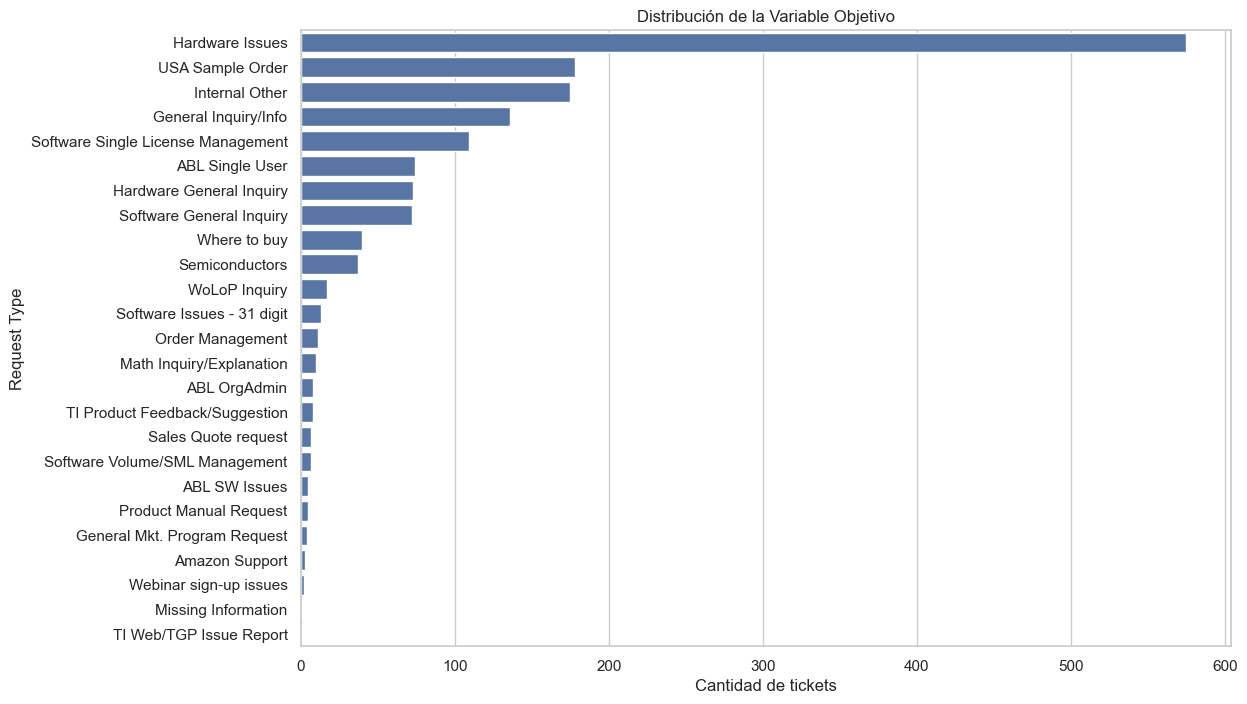

In [230]:
# Gráfica de distribución

plt.figure(figsize=(12,8))

sns.barplot(
    data=request_type,
    x="Cantidad",
    y="Request Type"
)

plt.title("Distribución de la Variable Objetivo")
plt.xlabel("Cantidad de tickets")
plt.ylabel("Request Type")

plt.show()

### Interpretación

La distribución de la variable objetivo evidencia que algunas categorías concentran un mayor número de solicitudes que otras. Este comportamiento indica un desbalance entre las clases, aspecto que deberá tenerse en cuenta durante la etapa de entrenamiento y evaluación de los modelos de Machine Learning.

Asimismo, se observa la presencia de registros sin una categoría asignada, los cuales serán tratados durante la fase de limpieza y preprocesamiento de los datos.

## Longitud de los Resúmenes de los Tickets

El campo **Summary** contiene una breve descripción de la solicitud realizada por el cliente y será la principal fuente de información para el entrenamiento del modelo.

Analizar la longitud de estos textos permite conocer la cantidad de información disponible en cada ticket y comprender mejor las características del conjunto de datos.

In [231]:
# Calcular longitud de los Summary

df["Summary_Length"] = (
    df["Summary"]
    .fillna("")
    .str.split()
    .str.len()
)

df["Summary_Length"].describe()

count    2199.000000
mean        6.562074
std         8.009357
min         1.000000
25%         2.000000
50%         4.000000
75%         9.000000
max       156.000000
Name: Summary_Length, dtype: float64

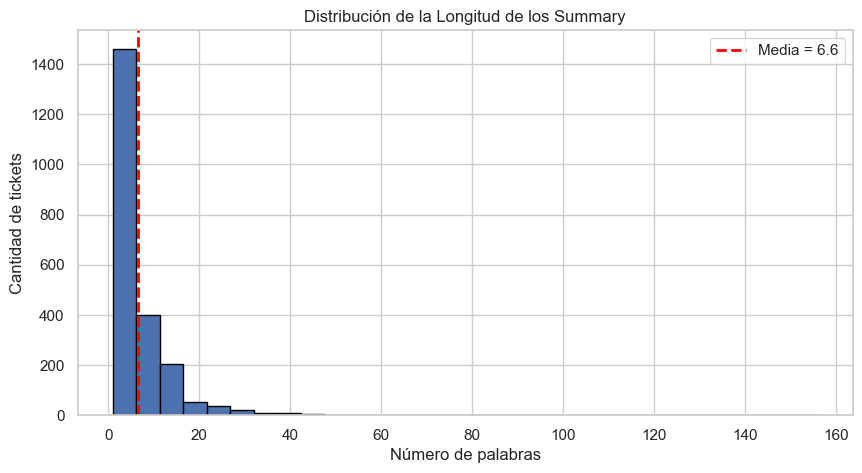

In [232]:
plt.figure(figsize=(10,5))

plt.hist(
    df["Summary_Length"],
    bins=30,
    edgecolor="black"
)

# Calcular la media
media = df["Summary_Length"].mean()

# Agregar una línea vertical en la media
plt.axvline(
    media,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Media = {media:.1f}"
)

plt.title("Distribución de la Longitud de los Summary")
plt.xlabel("Número de palabras")
plt.ylabel("Cantidad de tickets")

plt.legend()

plt.show()

### Interpretación

La distribución muestra que la mayoría de los resúmenes contienen un número reducido de palabras, con una longitud promedio de aproximadamente **6.6 palabras**. Asimismo, se observa una distribución asimétrica hacia la derecha, debido a la presencia de algunos tickets con descripciones considerablemente más extensas.

Este comportamiento es común en los sistemas de soporte técnico, donde la mayoría de los usuarios describen su problema de forma breve, mientras que un número reducido proporciona explicaciones más detalladas. Estas características deberán considerarse durante el preprocesamiento del texto y el entrenamiento de los modelos de clasificación.

## Análisis de la Longitud de los Resúmenes mediante un Boxplot

Además del histograma, se utiliza un diagrama de caja (*boxplot*) para analizar la distribución de la longitud de los resúmenes de los tickets.

Esta visualización permite identificar la mediana, el rango intercuartílico y la presencia de valores atípicos, proporcionando una visión más completa de la variabilidad existente en la longitud de los textos.

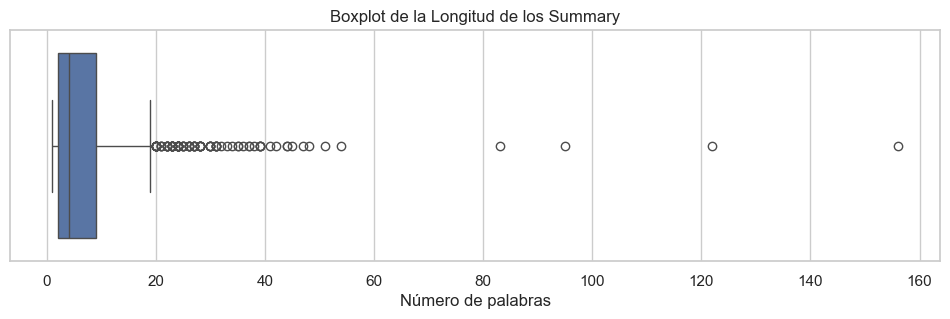

In [233]:
plt.figure(figsize=(12,3))

sns.boxplot(
    x=df["Summary_Length"]
)

plt.title("Boxplot de la Longitud de los Summary")
plt.xlabel("Número de palabras")

plt.show()

### Interpretación

El boxplot confirma la presencia de una distribución asimétrica hacia la derecha y evidencia la existencia de valores atípicos correspondientes a tickets con descripciones considerablemente más extensas que la mayoría.

No obstante, estos registros representan situaciones reales dentro del proceso de soporte técnico, por lo que no serán eliminados en esta etapa. Durante el preprocesamiento se evaluará si requieren algún tratamiento adicional.

## Palabras Más Frecuentes en los Resúmenes

El campo **Summary** constituye la principal fuente de información para el entrenamiento de los modelos de clasificación. Por esta razón, resulta útil analizar cuáles son las palabras que aparecen con mayor frecuencia en los tickets de soporte.

Antes de realizar el conteo, se eliminan las palabras vacías (*stopwords*) del idioma inglés, ya que estas no aportan información relevante para la clasificación y podrían afectar la interpretación de los resultados.

In [234]:
from nltk.corpus import stopwords
from collections import Counter
import nltk

nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

texto = " ".join(
    df["Summary"]
    .fillna("")
    .astype(str)
)

palabras = [
    palabra
    for palabra in texto.lower().split()
    if palabra.isalpha() and palabra not in stop_words
]

conteo = Counter(palabras)

top20 = pd.DataFrame(
    conteo.most_common(20),
    columns=["Palabra", "Frecuencia"]
)

top20

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Palabra,Frecuencia
0,summary,474
1,customer,354
2,plus,317
3,ce,303
4,ghost,288
5,validating,244
6,os,223
7,call,206
8,calculator,205
9,ti,153


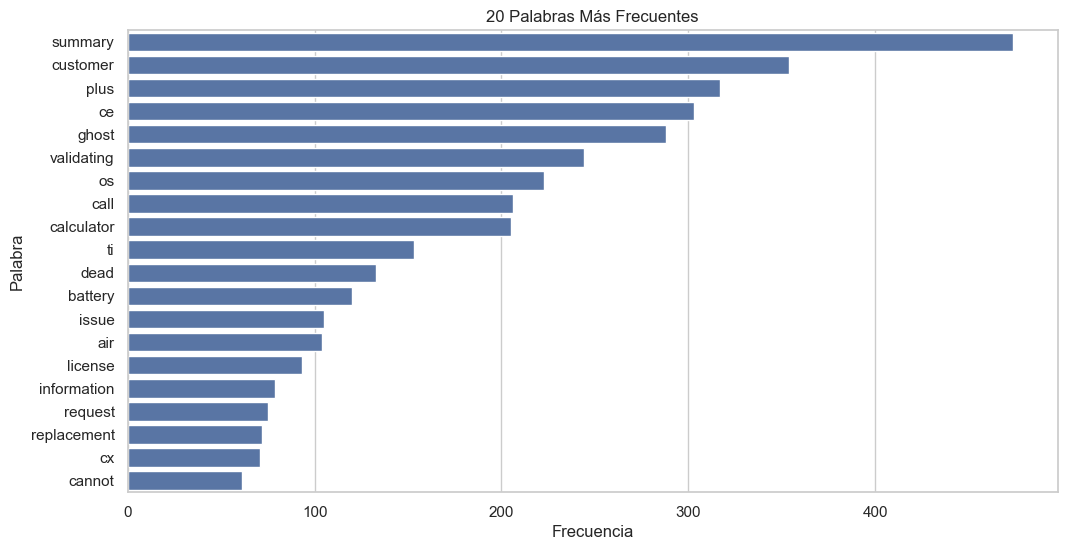

In [235]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top20,
    x="Frecuencia",
    y="Palabra"
)

plt.title("20 Palabras Más Frecuentes")
plt.xlabel("Frecuencia")
plt.ylabel("Palabra")

plt.show()

### Interpretación

Las palabras más frecuentes permiten identificar los temas predominantes en las solicitudes de soporte. Se observa que la mayoría de los términos están relacionados con procesos de activación, licenciamiento, calculadoras y software, lo cual es consistente con la naturaleza del servicio analizado.

Estos resultados confirman que el contenido del campo **Summary** contiene información relevante para entrenar un modelo de clasificación basado en texto.

## Nube de Palabras (WordCloud)

Como complemento al análisis de las palabras más frecuentes, se genera una nube de palabras (*WordCloud*), la cual permite visualizar de forma intuitiva los términos que aparecen con mayor frecuencia en los resúmenes de los tickets.

El tamaño de cada palabra es proporcional a su frecuencia de aparición, lo que facilita identificar rápidamente los conceptos predominantes dentro del conjunto de datos.

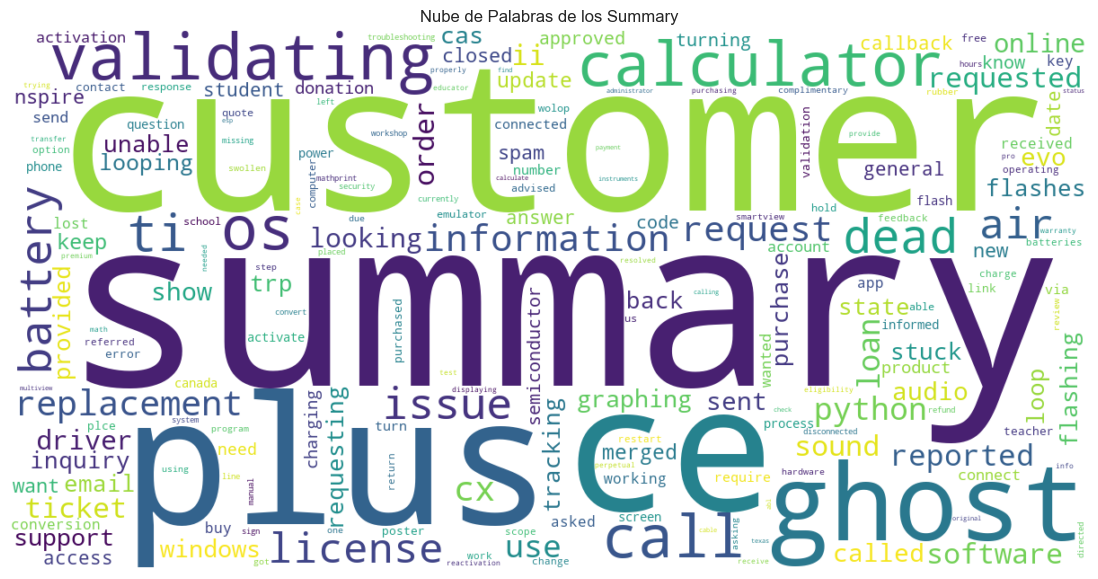

In [236]:
from wordcloud import WordCloud

texto_limpio = " ".join(palabras)

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    collocations=False
).generate(texto_limpio)

plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Nube de Palabras de los Summary")

plt.show()

### Interpretación

La nube de palabras confirma los resultados obtenidos en el análisis de frecuencias, destacando los términos más representativos presentes en los resúmenes de los tickets.

Se observa que predominan palabras relacionadas con procesos de activación, licenciamiento, calculadoras, software y soporte técnico, lo que evidencia que el contenido del campo **Summary** contiene información suficiente para abordar el problema de clasificación mediante técnicas de Procesamiento de Lenguaje Natural (NLP).

# Conclusiones del Análisis Exploratorio

El análisis exploratorio permitió comprender la estructura y calidad del conjunto de datos, así como identificar las variables más relevantes para el desarrollo del proyecto.

Los principales hallazgos fueron los siguientes:

- La variable **Request Type** presenta múltiples categorías y será utilizada como variable objetivo para el problema de clasificación.
- Se identificó un desbalance entre algunas clases, aspecto que deberá considerarse durante la evaluación de los modelos.
- Los resúmenes de los tickets son, en su mayoría, textos cortos, con una longitud promedio cercana a las siete palabras.
- Se observaron algunos valores atípicos correspondientes a descripciones más extensas; sin embargo, representan casos reales y no serán eliminados durante esta etapa.
- El análisis de las palabras más frecuentes y la nube de palabras evidencian que los resúmenes contienen información relacionada con licenciamiento, activación, software y calculadoras, lo que confirma que el campo **Summary** es una fuente adecuada para entrenar modelos de clasificación basados en texto.

Con base en estos resultados, el siguiente paso consiste en realizar la limpieza y el preprocesamiento de los datos, con el fin de preparar un conjunto de entrenamiento adecuado para los modelos de Machine Learning.

# Limpieza de los Datos

Una vez comprendida la estructura del conjunto de datos mediante el análisis exploratorio, se procede a realizar la limpieza de la información.

El objetivo de esta etapa es construir un conjunto de datos consistente y de calidad, eliminando registros incompletos o redundantes que puedan afectar el desempeño de los modelos de Machine Learning.

En esta fase se seleccionarán únicamente las variables necesarias para el problema de clasificación y se eliminarán aquellos registros que no contengan la información indispensable para el entrenamiento del modelo.

In [237]:
# Crear una copia para el modelado
df_model = df.copy()

## Selección de Variables para el Modelado

De acuerdo con la auditoría realizada anteriormente, el modelo utilizará únicamente las variables necesarias para resolver el problema de clasificación.

- **Summary**: corresponde al texto de entrada que describe la solicitud del cliente.
- **Request Type**: corresponde a la categoría que el modelo deberá predecir.

Las demás variables no serán utilizadas durante el entrenamiento, ya que no aportan información directamente relacionada con el objetivo del proyecto.

In [238]:
# Conservar únicamente las variables necesarias

df_model = df_model[["Summary", "Request Type"]]

df_model.head()

,Summary,Request Type
0,Out of scope.,Semiconductors
1,Unknown issue,General Inquiry/Info
2,semiconductor inquiry,Semiconductors
3,Battery not charging; directed customer to bat...,Hardware Issues
4,Customer Requesting Quote for charging cords a...,General Inquiry/Info


In [239]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 2199 entries, 0 to 2198
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Summary       2199 non-null   str  
 1   Request Type  1571 non-null   str  
dtypes: str(2)
memory usage: 147.9 KB


## Eliminación de Registros sin Resumen

Los registros que no contienen información en el campo **Summary** no pueden ser utilizados para entrenar un modelo basado en texto, ya que no existe contenido que permita identificar el tipo de solicitud.

Por esta razón, dichos registros serán eliminados del conjunto de datos.

In [240]:
# Cantidad de registros antes de eliminar valores faltantes

print("Antes:", len(df_model))

# Eliminar registros sin Summary

df_model = df_model.dropna(subset=["Summary"])

print("Después:", len(df_model))

Antes: 2199
Después: 2199


## Eliminación de Registros sin Variable Objetivo

Los registros que no cuentan con un valor en la variable **Request Type** no pueden utilizarse durante el entrenamiento supervisado, ya que el algoritmo requiere conocer la categoría correcta de cada ejemplo.

En consecuencia, estos registros serán eliminados del conjunto de datos.

In [241]:
print("Antes:", len(df_model))

df_model = df_model.dropna(subset=["Request Type"])

print("Después:", len(df_model))

Antes: 2199
Después: 1571


## Eliminación de Registros Duplicados

Finalmente, se eliminan los registros duplicados con el fin de evitar que una misma solicitud influya varias veces durante el entrenamiento del modelo.

Esta práctica contribuye a obtener un conjunto de datos más consistente y representativo.

In [242]:
print("Duplicados:", df_model.duplicated().sum())

df_model = df_model.drop_duplicates()

print("Duplicados después:", df_model.duplicated().sum())

Duplicados: 668
Duplicados después: 0


In [243]:
df_model.reset_index(drop=True, inplace=True)

df_model.head()

,Summary,Request Type
0,Out of scope.,Semiconductors
1,Unknown issue,General Inquiry/Info
2,semiconductor inquiry,Semiconductors
3,Battery not charging; directed customer to bat...,Hardware Issues
4,Customer Requesting Quote for charging cords a...,General Inquiry/Info


## Eliminación de Registros sin Información Descriptiva

Durante la revisión del conjunto de datos se identificaron registros cuyo campo **Summary** contenía el texto **"No Summary"**. Aunque estos registros no corresponden a valores nulos, no proporcionan información descriptiva sobre la solicitud realizada por el cliente.

Dado que el modelo de clasificación utilizará el contenido del campo **Summary** como variable de entrada, estos registros fueron eliminados para garantizar que el entrenamiento se realice únicamente con información relevante.

In [244]:
# Cantidad de registros con "No Summary"
print("Registros con 'No Summary':",
      (df_model["Summary"] == "No Summary").sum())

# Eliminar dichos registros
df_model = df_model[df_model["Summary"] != "No Summary"]

# Reiniciar índice
df_model.reset_index(drop=True, inplace=True)

# Verificación
df_model.info()

Registros con 'No Summary': 18
<class 'pandas.DataFrame'>
RangeIndex: 885 entries, 0 to 884
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Summary       885 non-null    str  
 1   Request Type  885 non-null    str  
dtypes: str(2)
memory usage: 88.1 KB


## Eliminación de Registros No Relacionados con el Problema de Clasificación

Durante la revisión final del conjunto de datos se identificaron algunos registros que no corresponden a solicitudes reales de soporte técnico, como casos de spam, llamadas sin interacción o solicitudes administrativas.

Dado que estos registros no representan el problema de clasificación planteado, fueron eliminados para mejorar la calidad del conjunto de entrenamiento.

In [245]:
import re

# Normalizar temporalmente el texto
summary_normalizado = (
    df_model["Summary"]
    .str.lower()
    .str.replace(r"[^\w\s]", "", regex=True)
    .str.strip()
)

eliminar = [
    "spam",
    "ghost call",
    "out of scope",
    "donations",
    "customer asked for a poster"
]

df_model = df_model[~summary_normalizado.isin(eliminar)]

df_model.reset_index(drop=True, inplace=True)

df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 853 entries, 0 to 852
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Summary       853 non-null    str  
 1   Request Type  853 non-null    str  
dtypes: str(2)
memory usage: 86.8 KB


## Verificación del Conjunto de Datos

Una vez finalizadas todas las actividades de limpieza, se verifica la estructura del conjunto de datos para confirmar que únicamente permanecen registros completos y relevantes para el entrenamiento del modelo.

In [246]:
df_model.info()

df_model.describe(include="object")

<class 'pandas.DataFrame'>
RangeIndex: 853 entries, 0 to 852
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Summary       853 non-null    str  
 1   Request Type  853 non-null    str  
dtypes: str(2)
memory usage: 86.8 KB


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9000\1260754791.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_model.describe(include="object")


,Summary,Request Type
count,853,853
unique,843,24
top,Purchase information request.,Hardware Issues
freq,2,333


## Conclusiones de la Limpieza de los Datos

Al finalizar esta etapa, el conjunto de datos quedó conformado únicamente por registros con información útil para el entrenamiento del modelo. Se eliminaron los registros sin variable objetivo, los registros duplicados y aquellos cuyo resumen no contenía información descriptiva.

Con este conjunto de datos limpio, el siguiente paso consiste en realizar el preprocesamiento del texto para transformarlo en una representación adecuada para los algoritmos de Machine Learning.

In [247]:
df_model.info()
df_model.describe(include="string")

<class 'pandas.DataFrame'>
RangeIndex: 853 entries, 0 to 852
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Summary       853 non-null    str  
 1   Request Type  853 non-null    str  
dtypes: str(2)
memory usage: 86.8 KB


,Summary,Request Type
count,853,853
unique,843,24
top,Purchase information request.,Hardware Issues
freq,2,333


# Preprocesamiento del Texto

En esta etapa se prepara el contenido de la variable **Summary** para que pueda ser utilizado por los algoritmos de Machine Learning.

El objetivo es normalizar los textos, eliminar elementos que no aportan información relevante y conservar aquellos términos que describen adecuadamente las solicitudes de soporte. Este proceso facilitará la transformación posterior del texto mediante técnicas de vectorización como **TF-IDF**.

## Creación de una Copia del Texto

Con el fin de conservar el contenido original de los resúmenes, se crea una nueva columna denominada **Summary_Clean**, sobre la cual se realizará todo el proceso de limpieza y normalización del texto.

In [248]:
df_model["Summary_Clean"] = df_model["Summary"]

## Conversión a Minúsculas

Como parte del proceso de normalización, todos los textos se convierten a minúsculas. Esto evita que palabras como **License**, **LICENSE** y **license** sean interpretadas como términos diferentes.

In [249]:
df_model["Summary_Clean"] = (
    df_model["Summary_Clean"]
    .str.lower()
)

## Eliminación de Espacios Innecesarios

Se eliminan los espacios adicionales presentes en los textos para obtener una representación más uniforme de la información.

In [250]:
df_model["Summary_Clean"] = (
    df_model["Summary_Clean"]
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

## Eliminación de URLs y Direcciones de Correo

Se eliminan enlaces web y direcciones de correo electrónico, ya que no aportan información relevante para la clasificación del tipo de solicitud.

In [251]:
import re

def limpiar_urls(texto):

    texto = re.sub(r"http\S+", "", texto)

    texto = re.sub(r"www\S+", "", texto)

    texto = re.sub(r"\S+@\S+", "", texto)

    return texto

df_model["Summary_Clean"] = (
    df_model["Summary_Clean"]
    .apply(limpiar_urls)
)

## Verificación del Texto Preprocesado

Antes de continuar con el proceso de limpieza, se comparan algunos registros del texto original con su versión normalizada. Esto permite verificar que las transformaciones realizadas hasta el momento conservan la información relevante para el problema de clasificación.

In [252]:
df_model[
    ["Summary", "Summary_Clean"]
].sample(10, random_state=42)

,Summary,Summary_Clean
66,TI-84 Plus CE Validating OS,ti-84 plus ce validating os
434,TI-84 Plus CE Python is Validating OS.,ti-84 plus ce python is validating os.
198,TI-Nspire CX II frozen screen,ti-nspire cx ii frozen screen
212,Customer was looking for information to calcul...,customer was looking for information to calcul...
652,Contact,contact
543,"Ghost call, no response","ghost call, no response"
280,Send posters,send posters
296,Amina cannot use the TI 84 Plus CE because Val...,amina cannot use the ti 84 plus ce because val...
365,Phone call regarding Windows 11 driver issue; ...,phone call regarding windows 11 driver issue; ...
679,Requesting more information for claculator tha...,requesting more information for claculator tha...


## Eliminación de Palabras Vacías (Stopwords)

Las palabras vacías (*stopwords*) son términos muy frecuentes en el idioma inglés, como *the*, *is*, *and* o *for*, que generalmente no aportan información relevante para diferenciar una categoría de otra.

Por esta razón, se eliminan del texto con el fin de reducir el ruido y conservar principalmente las palabras relacionadas con el problema de clasificación.

In [253]:
from nltk.corpus import stopwords
import nltk

# Descargar stopwords (solo la primera vez)
nltk.download("stopwords")

stop_words = set(stopwords.words("english"))

def eliminar_stopwords(texto):
    palabras = texto.split()
    palabras = [p for p in palabras if p not in stop_words]
    return " ".join(palabras)

df_model["Summary_Clean"] = (
    df_model["Summary_Clean"]
    .apply(eliminar_stopwords)
)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USUARIO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Comparación entre el Texto Original y el Texto Preprocesado

Con el fin de verificar que el proceso de limpieza conserva la información relevante para el problema de clasificación, se presenta una comparación entre algunos registros originales y su versión preprocesada.

Se observa que las transformaciones realizadas eliminan palabras poco informativas, mientras preservan términos técnicos importantes como modelos de calculadoras, versiones de software y conceptos relacionados con el soporte técnico.

In [254]:
df_model[
    ["Summary", "Summary_Clean"]
].sample(10, random_state=42)

,Summary,Summary_Clean
66,TI-84 Plus CE Validating OS,ti-84 plus ce validating os
434,TI-84 Plus CE Python is Validating OS.,ti-84 plus ce python validating os.
198,TI-Nspire CX II frozen screen,ti-nspire cx ii frozen screen
212,Customer was looking for information to calcul...,customer looking information calculate interes...
652,Contact,contact
543,"Ghost call, no response","ghost call, response"
280,Send posters,send posters
296,Amina cannot use the TI 84 Plus CE because Val...,amina cannot use ti 84 plus ce validating os.
365,Phone call regarding Windows 11 driver issue; ...,phone call regarding windows 11 driver issue; ...
679,Requesting more information for claculator tha...,requesting information claculator stopped working


# Vectorización del Texto mediante TF-IDF

Los algoritmos de Machine Learning no pueden trabajar directamente con texto, por lo que es necesario transformar los resúmenes de los tickets en una representación numérica.

Para ello se utiliza la técnica **TF-IDF (Term Frequency - Inverse Document Frequency)**, la cual asigna un peso a cada palabra de acuerdo con su importancia dentro de un documento y en todo el conjunto de datos.

De esta manera, las palabras más representativas de cada solicitud reciben un mayor peso, mientras que aquellas que aparecen con frecuencia en la mayoría de los documentos tienen una menor influencia en el modelo.

## Eliminación de Categorías con Muy Pocos Registros

Antes de dividir el conjunto de datos, se revisa la cantidad de registros por categoría. Las clases con un único ejemplo se eliminan, ya que no permiten realizar una división estratificada entre entrenamiento y prueba y, además, no proporcionan información suficiente para que el modelo aprenda sus características.

In [255]:
# Contar registros por categoría
conteo_clases = df_model["Request Type"].value_counts()

# Identificar categorías con menos de 2 registros
clases_pocas = conteo_clases[conteo_clases < 2].index

print("Clases eliminadas:")
print(clases_pocas.tolist())

# Eliminar esas categorías
df_model = df_model[~df_model["Request Type"].isin(clases_pocas)]

# Reiniciar índice
df_model.reset_index(drop=True, inplace=True)

# Verificar nuevamente
df_model["Request Type"].value_counts().tail()

Clases eliminadas:
['Missing Information', 'TI Web/TGP Issue Report']


Request Type
Sales Quote request             5
Product Manual Request          4
Amazon Support                  3
General Mkt. Program Request    2
Webinar sign-up issues          2
Name: count, dtype: int64

## Definición de Variables

Se separan las variables de entrada y la variable objetivo que serán utilizadas para entrenar los modelos de clasificación.

- **X:** contiene los textos preprocesados de los resúmenes.
- **y:** contiene la categoría correspondiente a cada solicitud.

In [256]:
X = df_model["Summary_Clean"]

y = df_model["Request Type"]

## División del Conjunto de Datos

El conjunto de datos se divide en dos subconjuntos:

- **Entrenamiento (80%)**, utilizado para construir los modelos.
- **Prueba (20%)**, utilizado para evaluar su capacidad de generalización sobre datos no vistos durante el entrenamiento.

In [257]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", len(X_train))
print("Prueba:", len(X_test))

Entrenamiento: 680
Prueba: 171


## Vectorización mediante TF-IDF

Una vez divididos los datos, se aplica la técnica **TF-IDF** para transformar los textos en vectores numéricos.

Es importante destacar que el vectorizador se ajusta (**fit**) únicamente con el conjunto de entrenamiento y posteriormente se utiliza para transformar (**transform**) tanto los datos de entrenamiento como los de prueba. Esto evita que el modelo utilice información del conjunto de prueba durante el entrenamiento y previene el problema conocido como **data leakage**.

In [258]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizador = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = vectorizador.fit_transform(X_train)

X_test_tfidf = vectorizador.transform(X_test)

## Verificación de la Vectorización

Finalmente, se verifica la dimensión de las matrices generadas mediante TF-IDF, con el fin de confirmar que los textos fueron transformados correctamente en una representación numérica apta para el entrenamiento de los modelos.

In [259]:
print("Entrenamiento:", X_train_tfidf.shape)
print("Prueba:", X_test_tfidf.shape)

Entrenamiento: (680, 957)
Prueba: (171, 957)


# Modelo 1. Multinomial Naive Bayes

Como primer modelo se utiliza **Multinomial Naive Bayes**, uno de los algoritmos más utilizados para problemas de clasificación de texto.

Este algoritmo asume independencia entre las características y suele ofrecer un buen desempeño cuando los documentos han sido representados mediante técnicas como **TF-IDF**, además de ser eficiente computacionalmente.

In [260]:
from sklearn.naive_bayes import MultinomialNB

modelo_nb = MultinomialNB()

modelo_nb.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## Predicción sobre el Conjunto de Prueba

Una vez entrenado el modelo, se generan las predicciones utilizando el conjunto de prueba para evaluar su capacidad de clasificación sobre datos no vistos previamente.

In [261]:
y_pred_nb = modelo_nb.predict(X_test_tfidf)

## Evaluación del Modelo

El desempeño del modelo se evalúa mediante las métricas de:

- Accuracy
- Precision
- Recall
- F1-Score

Estas métricas permiten analizar el comportamiento del algoritmo desde diferentes perspectivas y facilitarán posteriormente la comparación con los demás modelos.

In [262]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted",
    zero_division=0
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")

Accuracy : 0.4912
Precision: 0.4178
Recall   : 0.4912
F1 Score : 0.3711


In [263]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_nb,
        zero_division=0
    )
)

                                    precision    recall  f1-score   support

                      ABL OrgAdmin       0.00      0.00      0.00         1
                     ABL SW Issues       0.00      0.00      0.00         1
                   ABL Single User       0.00      0.00      0.00        12
                    Amazon Support       0.00      0.00      0.00         1
              General Inquiry/Info       1.00      0.12      0.22        16
          Hardware General Inquiry       0.00      0.00      0.00        11
                   Hardware Issues       0.48      0.97      0.64        67
                    Internal Other       0.75      0.33      0.46         9
          Math Inquiry/Explanation       0.00      0.00      0.00         2
                  Order Management       0.00      0.00      0.00         2
            Product Manual Request       0.00      0.00      0.00         1
               Sales Quote request       0.00      0.00      0.00         1
           

### Interpretación

El modelo **Multinomial Naive Bayes** obtuvo un desempeño aceptable como primer modelo de referencia. Los resultados obtenidos servirán como línea base para comparar el rendimiento de los siguientes algoritmos de clasificación.

# Modelo 2. Logistic Regression

Como segundo modelo se utiliza **Logistic Regression**, uno de los algoritmos más utilizados para problemas de clasificación de texto.

Este modelo busca encontrar la mejor relación entre las características del texto y las categorías de clasificación, ofreciendo generalmente un buen equilibrio entre precisión, capacidad de generalización e interpretabilidad.

In [264]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

modelo_lr.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

## Predicción sobre el Conjunto de Prueba

Se generan las predicciones utilizando el conjunto de prueba para evaluar el desempeño del modelo sobre datos que no fueron utilizados durante el entrenamiento.

In [265]:
y_pred_lr = modelo_lr.predict(X_test_tfidf)

## Evaluación del Modelo

El desempeño del modelo se evalúa utilizando las métricas de Accuracy, Precision, Recall y F1-Score, las cuales permiten medir la capacidad del algoritmo para clasificar correctamente las diferentes categorías de solicitudes.

In [266]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")

Accuracy : 0.5322
Precision: 0.4757
Recall   : 0.5322
F1 Score : 0.4462


# Comparación del Desempeño de los Modelos

Una vez entrenados los tres algoritmos de clasificación, se comparan sus resultados utilizando las métricas de **Accuracy**, **Precision**, **Recall** y **F1-Score**.

Esta comparación permite identificar el modelo con mejor capacidad de generalización y seleccionar la alternativa más adecuada para el problema de clasificación automática de tickets de soporte.

In [267]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        zero_division=0
    )
)

                                    precision    recall  f1-score   support

                      ABL OrgAdmin       0.00      0.00      0.00         1
                     ABL SW Issues       0.00      0.00      0.00         1
                   ABL Single User       1.00      0.17      0.29        12
                    Amazon Support       0.00      0.00      0.00         1
              General Inquiry/Info       0.22      0.12      0.16        16
          Hardware General Inquiry       0.00      0.00      0.00        11
                   Hardware Issues       0.54      0.96      0.69        67
                    Internal Other       0.75      0.33      0.46         9
          Math Inquiry/Explanation       0.00      0.00      0.00         2
                  Order Management       0.00      0.00      0.00         2
            Product Manual Request       0.00      0.00      0.00         1
               Sales Quote request       0.00      0.00      0.00         1
           

### Interpretación

El modelo **Logistic Regression** presentó una mejora respecto a **Multinomial Naive Bayes**, obteniendo valores superiores en Accuracy, Precision, Recall y F1-Score.

Estos resultados indican que Logistic Regression representa una alternativa más sólida para este problema de clasificación. Sin embargo, su desempeño será comparado posteriormente con el modelo **Random Forest** antes de seleccionar el algoritmo final.

# Modelo 3. Random Forest

Como tercer modelo se utiliza **Random Forest**, un algoritmo basado en un conjunto de árboles de decisión.

Este método construye múltiples árboles durante el entrenamiento y combina sus predicciones para obtener un resultado final. Random Forest suele ofrecer buenos resultados en diferentes problemas de clasificación gracias a su capacidad para reducir el sobreajuste y mejorar la generalización del modelo.

In [268]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train_tfidf, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Predicción sobre el Conjunto de Prueba

Se generan las predicciones del modelo utilizando el conjunto de prueba para evaluar su capacidad de clasificación sobre datos que no participaron en el entrenamiento.

## Evaluación del Modelo

El rendimiento del modelo se mide mediante las métricas de Accuracy, Precision, Recall y F1-Score, permitiendo comparar sus resultados con los obtenidos por los modelos anteriores.

In [269]:
y_pred_rf = modelo_rf.predict(X_test_tfidf)

In [270]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1 Score : {f1_rf:.4f}")

Accuracy : 0.5789
Precision: 0.5293
Recall   : 0.5789
F1 Score : 0.5251


In [271]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

                                    precision    recall  f1-score   support

                      ABL OrgAdmin       0.00      0.00      0.00         1
                     ABL SW Issues       1.00      1.00      1.00         1
                   ABL Single User       0.57      0.33      0.42        12
                    Amazon Support       0.00      0.00      0.00         1
              General Inquiry/Info       0.33      0.31      0.32        16
          Hardware General Inquiry       0.25      0.09      0.13        11
                   Hardware Issues       0.65      0.96      0.77        67
                    Internal Other       0.75      0.33      0.46         9
          Math Inquiry/Explanation       0.00      0.00      0.00         2
                  Order Management       0.00      0.00      0.00         2
            Product Manual Request       0.00      0.00      0.00         1
               Sales Quote request       0.00      0.00      0.00         1
           

### Interpretación

El modelo **Random Forest** obtuvo el mejor desempeño entre los algoritmos evaluados, alcanzando los valores más altos de Accuracy, Precision, Recall y F1-Score.

Por esta razón, se selecciona como el modelo más adecuado para la clasificación automática de los tickets de soporte en este proyecto.

# Comparación del Desempeño de los Modelos

Una vez entrenados los tres modelos de clasificación, se comparan sus resultados utilizando las métricas de **Accuracy**, **Precision**, **Recall** y **F1-Score**.

Esta comparación permite identificar el algoritmo con mejor capacidad de clasificación y seleccionar el modelo más adecuado para la automatización de la clasificación de tickets de soporte.

In [272]:
resultados = []

In [273]:
resultados.append({
    "Modelo": "Multinomial Naive Bayes",
    "Accuracy": accuracy_nb,
    "Precision": precision_nb,
    "Recall": recall_nb,
    "F1-Score": f1_nb
})

In [274]:
resultados.append({
    "Modelo": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1-Score": f1_lr
})

In [275]:
resultados.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-Score": f1_rf
})

In [276]:
resultados_df = pd.DataFrame(resultados)

resultados_df = resultados_df.round(4)

resultados_df

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.4912,0.4178,0.4912,0.3711
1,Logistic Regression,0.5322,0.4757,0.5322,0.4462
2,Random Forest,0.5789,0.5293,0.5789,0.5251


## Comparación Visual de las Métricas

Para facilitar la interpretación de los resultados obtenidos, se presenta una gráfica de barras con las principales métricas de evaluación de cada modelo.

Esta visualización permite identificar de manera rápida cuál algoritmo ofrece el mejor desempeño para el problema de clasificación planteado.

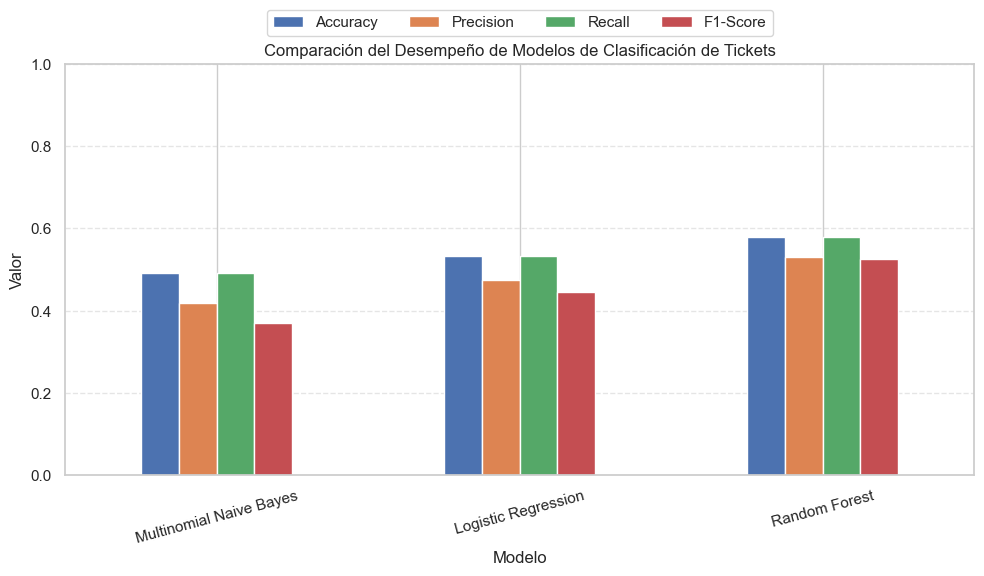

In [277]:
import matplotlib.pyplot as plt

grafica = resultados_df.set_index("Modelo")

grafica.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparación del Desempeño de Modelos de Clasificación de Tickets")

plt.ylabel("Valor")

plt.xlabel("Modelo")

plt.xticks(rotation=15)

plt.ylim(0,1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=4
)
plt.tight_layout()

plt.show()

### Interpretación

La comparación de métricas muestra una mejora progresiva entre los modelos evaluados.

**Multinomial Naive Bayes** sirvió como modelo base, **Logistic Regression** mejoró todas las métricas obtenidas inicialmente y **Random Forest** alcanzó el mejor desempeño general.

De acuerdo con los resultados obtenidos, **Random Forest** fue el algoritmo con mayor Accuracy, Precision, Recall y F1-Score, por lo que se selecciona como el modelo más adecuado para este problema de clasificación.

# Matriz de Confusión del Modelo Seleccionado

Tras comparar los tres modelos mediante las métricas de evaluación, **Random Forest** fue seleccionado como el algoritmo con mejor desempeño.

A continuación se presenta la matriz de confusión correspondiente a este modelo, la cual permite visualizar la relación entre las clases reales y las clases predichas.

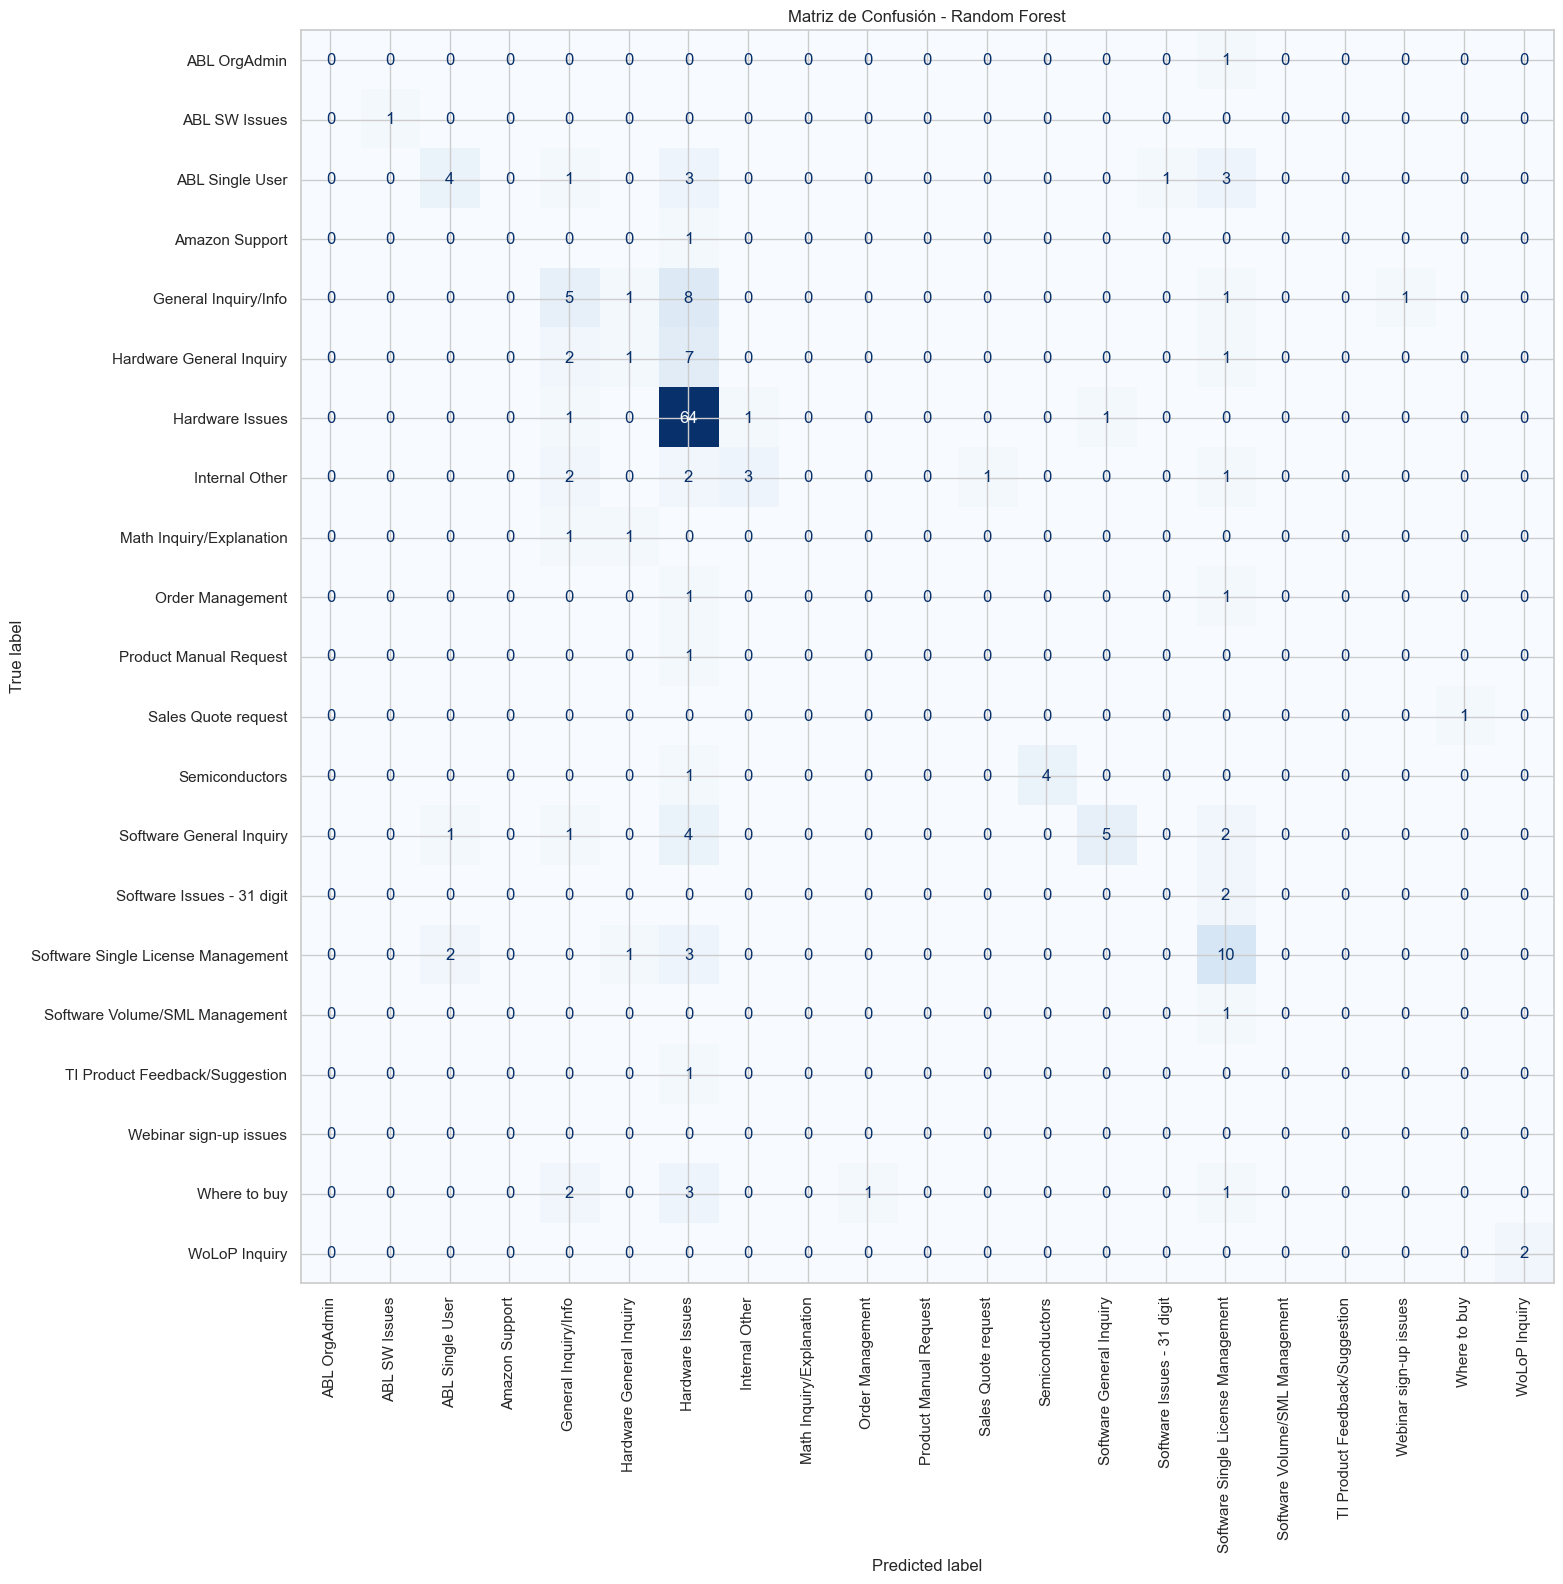

In [278]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16,16))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    cmap="Blues",
    xticks_rotation=90,
    colorbar=False,
    ax=ax
)

plt.title("Matriz de Confusión - Random Forest")

plt.tight_layout()

plt.show()

### Interpretación

La matriz de confusión permite observar el comportamiento del modelo **Random Forest** sobre el conjunto de prueba.

La mayor concentración de valores sobre la diagonal principal indica que el modelo logra clasificar correctamente una parte importante de las solicitudes.

Los errores de clasificación se presentan principalmente en categorías con pocos registros, comportamiento esperado debido al desbalance del conjunto de datos identificado durante el análisis exploratorio.

En conjunto con las métricas obtenidas, estos resultados respaldan la selección de **Random Forest** como el modelo con mejor desempeño para este proyecto.

# Conclusiones

En este proyecto se desarrolló un modelo de Machine Learning para la clasificación automática de tickets de soporte técnico utilizando técnicas de procesamiento de lenguaje natural y algoritmos de clasificación supervisada.

Durante el proceso se realizó la exploración, limpieza y preprocesamiento de los datos, incluyendo la eliminación de registros inconsistentes, normalización del texto y vectorización mediante TF-IDF.

Posteriormente se entrenaron tres modelos de clasificación: **Multinomial Naive Bayes**, **Logistic Regression** y **Random Forest**, evaluando su desempeño mediante las métricas Accuracy, Precision, Recall y F1-Score.

Los resultados mostraron una mejora progresiva entre los modelos evaluados, siendo **Random Forest** el algoritmo con mejor desempeño, alcanzando un Accuracy de **57.89 %** y el mayor F1-Score del estudio.

Aunque el conjunto de datos presenta un importante desbalance entre categorías, el modelo seleccionado demostró una capacidad adecuada para clasificar automáticamente las solicitudes más frecuentes, constituyendo una base sólida para apoyar procesos de atención y priorización de tickets de soporte.

# Prueba del Modelo con Nuevos Tickets

Finalmente, se realizan algunas pruebas utilizando nuevas solicitudes de soporte que no pertenecen al conjunto de datos original.

El objetivo es demostrar cómo el modelo entrenado puede clasificar automáticamente nuevos tickets a partir de la descripción suministrada por el usuario.

In [279]:
import re

def limpiar_texto(texto):
    # Minúsculas
    texto = texto.lower()

    # Eliminar URLs
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"www\S+", "", texto)
    texto = re.sub(r"\S+@\S+", "", texto)

    # Eliminar espacios extra
    texto = re.sub(r"\s+", " ", texto)

    return texto.strip()

In [280]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r"http\S+", "", texto)
    texto = re.sub(r"www\S+", "", texto)
    texto = re.sub(r"\S+@\S+", "", texto)
    texto = re.sub(r"\s+", " ", texto)
    return texto.strip()

nuevos_tickets = [
    "Calculator stuck on validating OS.",
    "Windows 11 driver issue.",
    "Need help with software activation.",
    "Need to manage a single user license."
]

# Aplicar el mismo preprocesamiento
nuevos_tickets_clean = [limpiar_texto(ticket) for ticket in nuevos_tickets]

# Vectorizar
X_nuevo = vectorizador.transform(nuevos_tickets_clean)

# Predecir
predicciones = modelo_rf.predict(X_nuevo)

resultados_prediccion = pd.DataFrame({
    "Nuevo Ticket": nuevos_tickets,
    "Categoría Predicha": predicciones
})

resultados_prediccion

,Nuevo Ticket,Categoría Predicha
0,Calculator stuck on validating OS.,Hardware Issues
1,Windows 11 driver issue.,Software General Inquiry
2,Need help with software activation.,ABL Single User
3,Need to manage a single user license.,Software Single License Management


### Interpretación

Las pruebas realizadas con nuevos ejemplos muestran que el modelo es capaz de clasificar automáticamente solicitudes de soporte que no hicieron parte del conjunto de entrenamiento.

Las categorías predichas son coherentes con el contenido de los tickets evaluados, evidenciando que el modelo aprendió patrones relevantes del conjunto de datos y puede utilizarse como apoyo en la clasificación inicial de solicitudes.

Aunque el modelo aún presenta limitaciones debido al desbalance entre las categorías del dataset, los resultados obtenidos demuestran el potencial de aplicar técnicas de Machine Learning para automatizar procesos de atención y priorización de tickets de soporte.